In [1]:
#pip install ISLP

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from ISLP import load_data

In [3]:
# Load the Boston dataset
boston = load_data("Boston")

# Define features (X) and target (y)
X = boston.drop(columns='medv')
y = boston['medv']

# Standardize the features (as PLS is sensitive to data scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=8)


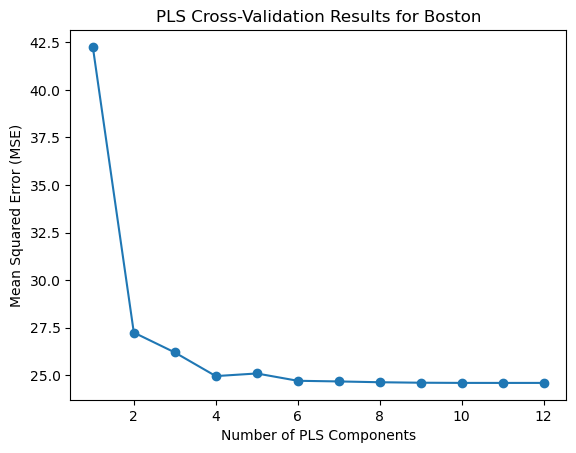

In [5]:
### Cross-validation to select the optimal number of components for PLS
mse_values = []  # Store the MSE for each number of components

# Perform cross-validation for different numbers of components
for n_components in range(1, X_train.shape[1] + 1):
    # Initialize PLS with n_components
    pls_model = PLSRegression(n_components=n_components)

    # Perform 5-fold cross-validation and calculate the MSE
    mse = -np.mean(cross_val_score(pls_model, X_train, y_train, scoring='neg_mean_squared_error', cv=5))
    mse_values.append(mse)

# Ensure mse_values contains the same number of elements as the number of components tested
n_components_tested = len(mse_values)

# Plot the cross-validation results to visualize the best number of components
plt.plot(range(1, n_components_tested + 1), mse_values, marker='o')
plt.xlabel('Number of PLS Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('PLS Cross-Validation Results for Boston')
plt.show()

In [6]:
# Find the optimal number of components (minimizing MSE)
best_n_components_pls = np.argmin(mse_values) + 1
print(f"Optimal number of PLS components for Boston: {best_n_components_pls}")


Optimal number of PLS components for Boston: 11


In [7]:
### Refit PLS model using the optimal number of components on the full training set
# Fit the PLS model with the optimal number of components
pls_best_model = PLSRegression(n_components=best_n_components_pls)
pls_best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pls_best_model.predict(X_test)

# Calculate the MSE on the test set
pls_mse = mean_squared_error(y_test, y_pred)
print(f"PLS MSE on test set with {best_n_components_pls} components: {pls_mse}")


PLS MSE on test set with 11 components: 26.757514058295122


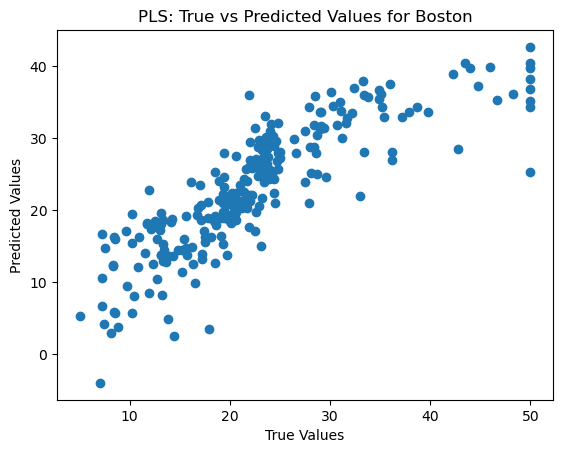

In [8]:
# Plot the actual vs predicted values for the PLS model
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('PLS: True vs Predicted Values for Boston')
plt.show()

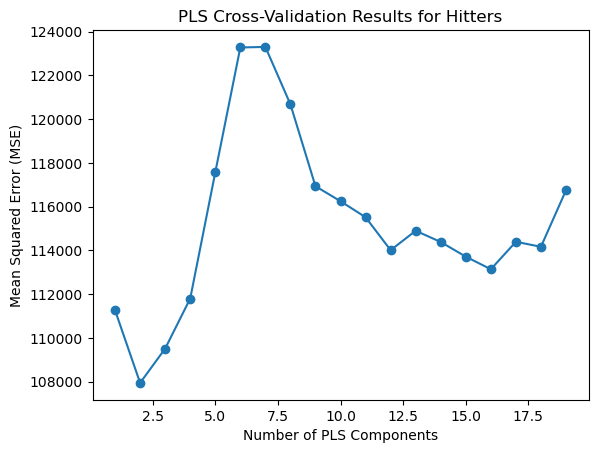

Optimal number of PLS components for Hitters: 2
PLS MSE on test set with 2 components: 159032.40876305656


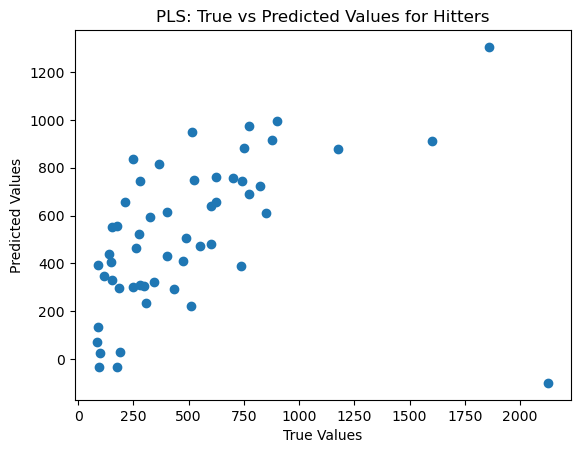

In [9]:
# Load the Hitters dataset
hitters = load_data("Hitters")

# Drop missing values
hitters = hitters.dropna()

# Define features (X) and target (y)
X = hitters.drop(columns='Salary')
y = hitters['Salary']

# One-hot encode categorical variables (necessary for non-numeric data)
X = pd.get_dummies(X, drop_first=True)

# Standardize the features (as PLS is sensitive to data scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Cross-validation to select the optimal number of components for PLS
mse_values = []  # Store the MSE for each number of components

# Perform cross-validation for different numbers of components
for n_components in range(1, X_train.shape[1] + 1):
    # Initialize PLS with n_components
    pls_model = PLSRegression(n_components=n_components)

    # Perform 5-fold cross-validation and calculate the MSE
    mse = -np.mean(cross_val_score(pls_model, X_train, y_train, scoring='neg_mean_squared_error', cv=5))
    mse_values.append(mse)

# Ensure mse_values contains the same number of elements as the number of components tested
n_components_tested = len(mse_values)

# Plot the cross-validation results to visualize the best number of components
plt.plot(range(1, n_components_tested + 1), mse_values, marker='o')
plt.xlabel('Number of PLS Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('PLS Cross-Validation Results for Hitters')
plt.show()

# Find the optimal number of components (minimizing MSE)
best_n_components_pls = np.argmin(mse_values) + 1
print(f"Optimal number of PLS components for Hitters: {best_n_components_pls}")

### Refit PLS model using the optimal number of components on the full training set
# Fit the PLS model with the optimal number of components
pls_best_model = PLSRegression(n_components=best_n_components_pls)
pls_best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pls_best_model.predict(X_test)

# Calculate the MSE on the test set
pls_mse = mean_squared_error(y_test, y_pred)
print(f"PLS MSE on test set with {best_n_components_pls} components: {pls_mse}")

# Plot the actual vs predicted values for the PLS model
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('PLS: True vs Predicted Values for Hitters')
plt.show()